# F1 Harness Ablation Visualization

This notebook visualizes Hermes benchmark JSONL outputs across harness configs. It focuses on Q/L/C/R:

- Q: oracle pass rate
- L: wall-clock latency
- C: input/output token cost and API calls
- R: retry/fallback/budget/stuck risk signals

Expected inputs live in `benchmark/results/*.jsonl`, for example `f1_baseline.jsonl` and `f1_file_only.jsonl`.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("ggplot")
pd.set_option("display.max_colwidth", 120)

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent.parent
RESULTS_DIR = ROOT / "benchmark" / "results"
RESULT_FILES = sorted(RESULTS_DIR.glob("f1_*.jsonl"))
RESULT_FILES

[PosixPath('/home/nan/c_project/hfa/benchmark/results/f1_baseline.jsonl'),
 PosixPath('/home/nan/c_project/hfa/benchmark/results/f1_file_only.jsonl')]

In [2]:
def infer_config_name(path: Path) -> str:
    name = path.stem
    if name.startswith("f1_"):
        name = name[3:]
    return name


def load_jsonl(path: Path) -> list[dict]:
    rows = []
    for line in path.read_text().splitlines():
        line = line.strip()
        if line:
            rows.append(json.loads(line))
    return rows


def flatten_record(record: dict, source_file: Path) -> dict:
    metrics = record.get("metrics") or {}
    runtime = record.get("runtime") or {}
    action_gate = record.get("action_gate") or []
    exposure = next((e for e in action_gate if e.get("type") == "action_gate_exposure"), {})
    policy = next((e for e in action_gate if e.get("type") == "action_gate_policy"), {})
    policy_body = policy.get("policy") or {}
    return {
        "config": infer_config_name(source_file),
        "source_file": source_file.name,
        "task_id": record.get("task_id"),
        "seed": record.get("seed"),
        "family": record.get("family"),
        "q_pass": bool(metrics.get("q_oracle_pass")),
        "latency_s": metrics.get("l_wall_clock_sec", 0),
        "input_tokens": metrics.get("c_input_tokens", 0),
        "output_tokens": metrics.get("c_output_tokens", 0),
        "reasoning_tokens": metrics.get("c_reasoning_tokens", 0),
        "total_tokens": metrics.get("c_input_tokens", 0) + metrics.get("c_output_tokens", 0) + metrics.get("c_reasoning_tokens", 0),
        "api_calls": record.get("api_calls", 0),
        "retry_count": metrics.get("r_retry_count", 0),
        "fallback_count": metrics.get("r_fallback_count", 0),
        "iter_budget_hit": bool(metrics.get("r_iter_budget_hit")),
        "turn_budget_hit": bool(metrics.get("r_turn_budget_hit")),
        "stuck": bool(metrics.get("r_stuck")),
        "stop_reason": record.get("stop_reason"),
        "provider": runtime.get("effective_provider") or record.get("provider"),
        "model": runtime.get("effective_model") or record.get("model"),
        "base_url": runtime.get("effective_base_url") or record.get("base_url"),
        "api_key_source": runtime.get("api_key_source"),
        "enabled_tools": ", ".join(exposure.get("enabled_tools") or []),
        "enabled_toolsets": ", ".join(policy_body.get("enabled_toolsets") or []),
        "allow_tools": ", ".join(policy_body.get("allow_tools") or []),
        "deny_tools": ", ".join(policy_body.get("deny_tools") or []),
        "final_message": record.get("final_message", ""),
    }


rows = []
for path in RESULT_FILES:
    for record in load_jsonl(path):
        rows.append(flatten_record(record, path))

df = pd.DataFrame(rows)
df.head()

,config,source_file,task_id,seed,family,q_pass,latency_s,input_tokens,output_tokens,reasoning_tokens,...,stop_reason,provider,model,base_url,api_key_source,enabled_tools,enabled_toolsets,allow_tools,deny_tools,final_message
0,baseline,f1_baseline.jsonl,f1_01_version,0,F1_code_qa,True,22.908460,3276,179,0,...,completed,kimi-coding,kimi-k2.6,NaN,NaN,,,,,0.10.0
1,baseline,f1_baseline.jsonl,f1_01_version,1,F1_code_qa,True,15.681555,3256,428,0,...,completed,kimi-coding,kimi-k2.6,NaN,NaN,,,,,0.10.0
2,baseline,f1_baseline.jsonl,f1_01_version,2,F1_code_qa,True,19.078578,1069,332,0,...,completed,kimi-coding,kimi-k2.6,NaN,NaN,,,,,0.10.0
3,baseline,f1_baseline.jsonl,f1_02_iteration_budget_class,0,F1_code_qa,True,12.047827,7153,225,0,...,completed,kimi-coding,kimi-k2.6,NaN,NaN,,,,,IterationBudget
4,baseline,f1_baseline.jsonl,f1_02_iteration_budget_class,1,F1_code_qa,True,17.491513,2703,291,0,...,completed,kimi-coding,kimi-k2.6,NaN,NaN,,,,,IterationBudget


In [3]:
df.groupby("config").agg(
    runs=("task_id", "count"),
    pass_rate=("q_pass", "mean"),
    latency_mean=("latency_s", "mean"),
    latency_median=("latency_s", "median"),
    latency_max=("latency_s", "max"),
    input_tokens_mean=("input_tokens", "mean"),
    input_tokens_median=("input_tokens", "median"),
    input_tokens_max=("input_tokens", "max"),
    output_tokens_mean=("output_tokens", "mean"),
    api_calls_mean=("api_calls", "mean"),
    api_calls_max=("api_calls", "max"),
    retries=("retry_count", "sum"),
    fallbacks=("fallback_count", "sum"),
    iter_budget_hits=("iter_budget_hit", "sum"),
    stuck_runs=("stuck", "sum"),
).round(3)

,runs,pass_rate,latency_mean,latency_median,latency_max,input_tokens_mean,input_tokens_median,input_tokens_max,output_tokens_mean,api_calls_mean,api_calls_max,retries,fallbacks,iter_budget_hits,stuck_runs
config,,,,,,,,,,,,,,,
baseline,30,1.0,16.433,12.483,46.366,3886.333,1400.0,25841,318.333,3.167,9,0,0,0,0
file_only,30,1.0,25.893,17.415,89.347,2821.033,1915.5,13214,260.267,3.333,9,0,0,0,0


## Config-Level Q/L/C/R

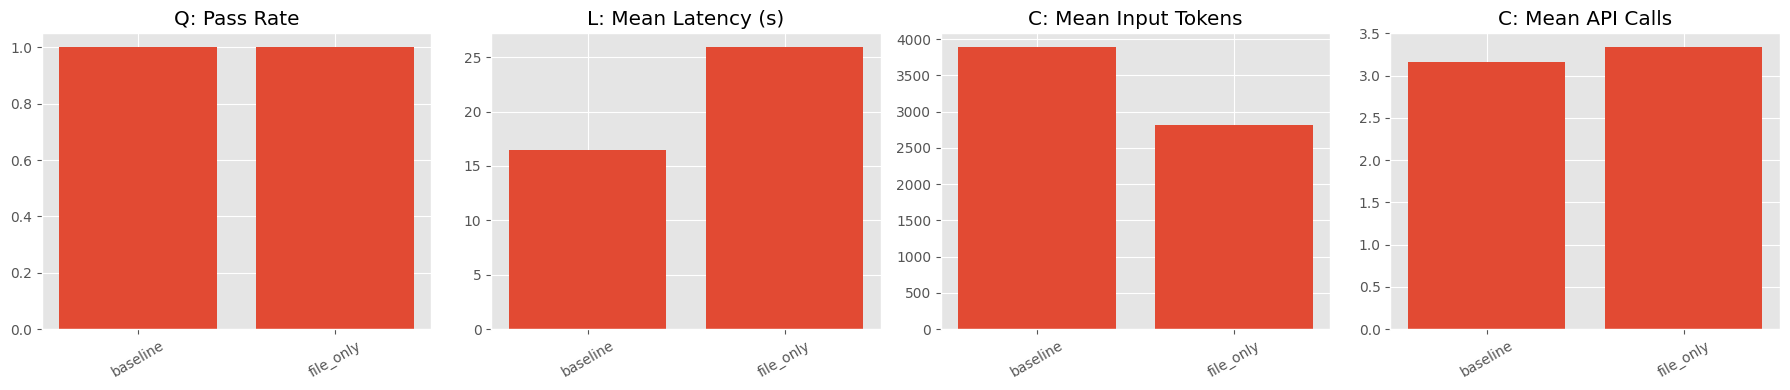

,config,pass_rate,latency_s,input_tokens,api_calls,risk_events
0,baseline,1.0,16.433488,3886.333333,3.166667,0
1,file_only,1.0,25.893228,2821.033333,3.333333,0


In [4]:
summary = df.groupby("config").agg(
    pass_rate=("q_pass", "mean"),
    latency_s=("latency_s", "mean"),
    input_tokens=("input_tokens", "mean"),
    api_calls=("api_calls", "mean"),
    risk_events=("retry_count", "sum"),
).reset_index()
summary["risk_events"] += df.groupby("config")[["fallback_count", "iter_budget_hit", "turn_budget_hit", "stuck"]].sum().sum(axis=1).values

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col, title in zip(
    axes,
    ["pass_rate", "latency_s", "input_tokens", "api_calls"],
    ["Q: Pass Rate", "L: Mean Latency (s)", "C: Mean Input Tokens", "C: Mean API Calls"],
):
    ax.bar(summary["config"], summary[col])
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

summary

## Per-Task Quality Heatmap

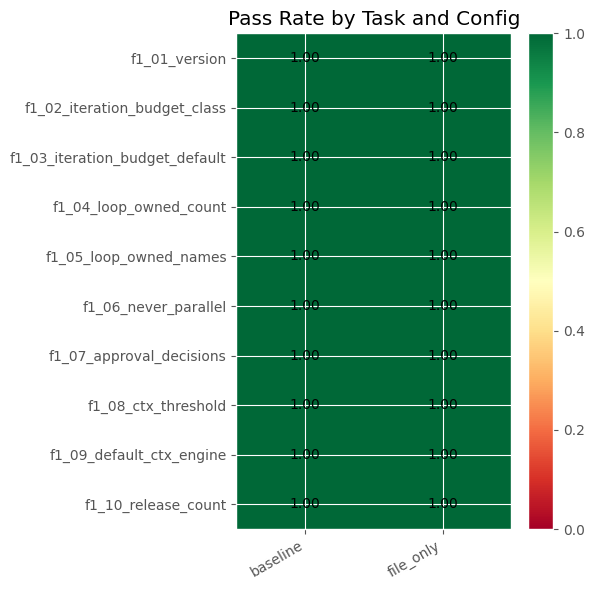

config,baseline,file_only
task_id,,
f1_01_version,1.0,1.0
f1_02_iteration_budget_class,1.0,1.0
f1_03_iteration_budget_default,1.0,1.0
f1_04_loop_owned_count,1.0,1.0
f1_05_loop_owned_names,1.0,1.0
f1_06_never_parallel,1.0,1.0
f1_07_approval_decisions,1.0,1.0
f1_08_ctx_threshold,1.0,1.0
f1_09_default_ctx_engine,1.0,1.0


In [5]:
quality = df.groupby(["task_id", "config"])["q_pass"].mean().unstack("config")

fig, ax = plt.subplots(figsize=(max(6, len(quality.columns) * 2), 6))
im = ax.imshow(quality.values, aspect="auto", vmin=0, vmax=1, cmap="RdYlGn")
ax.set_xticks(range(len(quality.columns)))
ax.set_xticklabels(quality.columns, rotation=30, ha="right")
ax.set_yticks(range(len(quality.index)))
ax.set_yticklabels(quality.index)
ax.set_title("Pass Rate by Task and Config")
for i, task in enumerate(quality.index):
    for j, config in enumerate(quality.columns):
        ax.text(j, i, f"{quality.iloc[i, j]:.2f}", ha="center", va="center", color="black")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

quality

## Latency and Cost Distributions

/tmp/ipykernel_170446/1920068260.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showmeans=True)
/tmp/ipykernel_170446/1920068260.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showmeans=True)
/tmp/ipykernel_170446/1920068260.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showmeans=True)


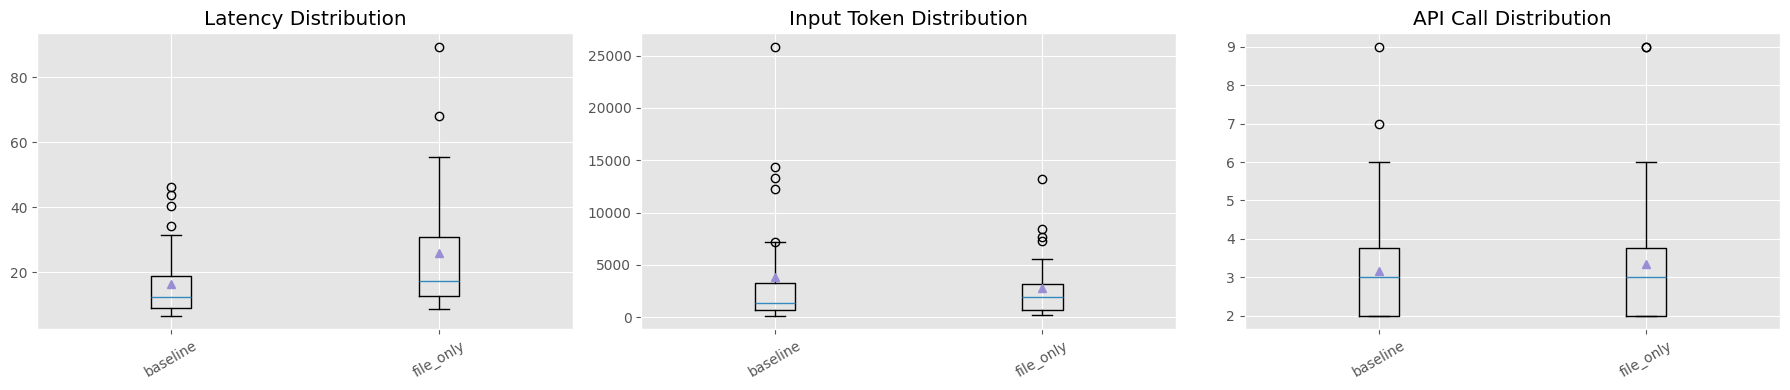

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, col, title in zip(
    axes,
    ["latency_s", "input_tokens", "api_calls"],
    ["Latency Distribution", "Input Token Distribution", "API Call Distribution"],
):
    groups = [g[col].dropna().values for _, g in df.groupby("config")]
    labels = [name for name, _ in df.groupby("config")]
    ax.boxplot(groups, labels=labels, showmeans=True)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## Task-Level Delta vs Baseline

,task_id,config,latency_delta_s,input_tokens_delta,api_calls_delta
6,f1_07_approval_decisions,file_only,32.046168,-8069.666667,0.666667
7,f1_08_ctx_threshold,file_only,21.939801,90.333333,0.000000
3,f1_04_loop_owned_count,file_only,16.858371,825.666667,0.666667
0,f1_01_version,file_only,13.403626,43.333333,-0.333333
4,f1_05_loop_owned_names,file_only,3.201736,575.333333,-0.333333
5,f1_06_never_parallel,file_only,2.918008,189.333333,0.000000
9,f1_10_release_count,file_only,2.363664,-20.666667,0.000000
8,f1_09_default_ctx_engine,file_only,2.335318,-140.333333,0.666667
2,f1_03_iteration_budget_default,file_only,0.052191,-1652.666667,0.000000
1,f1_02_iteration_budget_class,file_only,-0.521480,-2493.666667,0.333333


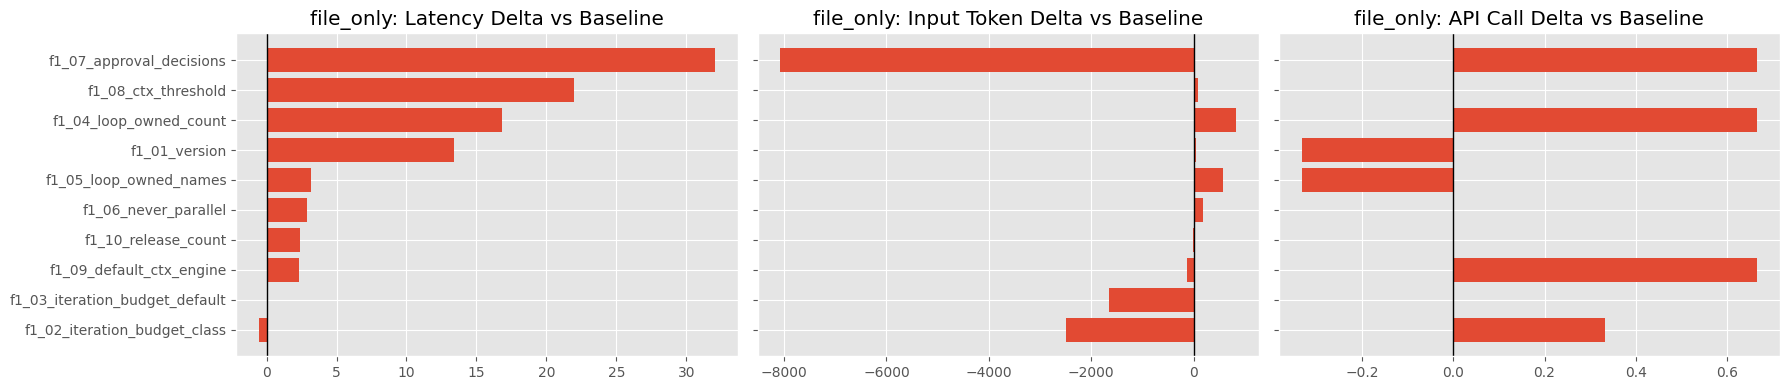

In [7]:
metric_means = df.groupby(["task_id", "config"])[["latency_s", "input_tokens", "api_calls"]].mean().reset_index()
baseline_name = "baseline"

if baseline_name in set(metric_means["config"]):
    base = metric_means[metric_means["config"] == baseline_name].set_index("task_id")
    deltas = []
    for _, row in metric_means[metric_means["config"] != baseline_name].iterrows():
        task = row["task_id"]
        if task not in base.index:
            continue
        deltas.append({
            "task_id": task,
            "config": row["config"],
            "latency_delta_s": row["latency_s"] - base.loc[task, "latency_s"],
            "input_tokens_delta": row["input_tokens"] - base.loc[task, "input_tokens"],
            "api_calls_delta": row["api_calls"] - base.loc[task, "api_calls"],
        })
    delta_df = pd.DataFrame(deltas)
    display(delta_df.sort_values(["config", "latency_delta_s"], ascending=[True, False]))

    for config, g in delta_df.groupby("config"):
        fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)
        g = g.sort_values("latency_delta_s")
        for ax, col, title in zip(
            axes,
            ["latency_delta_s", "input_tokens_delta", "api_calls_delta"],
            ["Latency Delta vs Baseline", "Input Token Delta vs Baseline", "API Call Delta vs Baseline"],
        ):
            ax.barh(g["task_id"], g[col])
            ax.axvline(0, color="black", linewidth=1)
            ax.set_title(f"{config}: {title}")
        plt.tight_layout()
        plt.show()
else:
    print("No baseline config found. Current configs:", sorted(metric_means["config"].unique()))

## Pareto View: Quality vs Cost/Latency

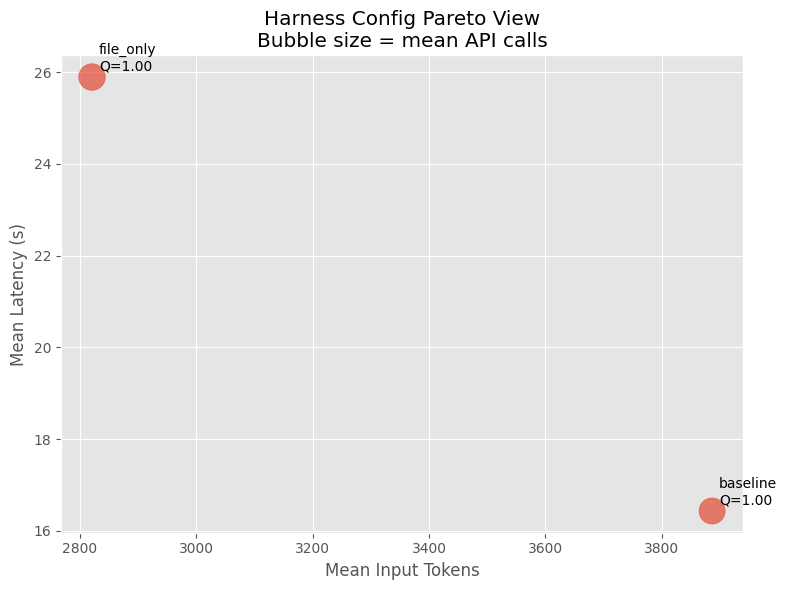

,config,pass_rate,latency_s,input_tokens,api_calls
0,baseline,1.0,16.433488,3886.333333,3.166667
1,file_only,1.0,25.893228,2821.033333,3.333333


In [8]:
pareto = df.groupby("config").agg(
    pass_rate=("q_pass", "mean"),
    latency_s=("latency_s", "mean"),
    input_tokens=("input_tokens", "mean"),
    api_calls=("api_calls", "mean"),
).reset_index()

fig, ax = plt.subplots(figsize=(8, 6))
sizes = 100 + pareto["api_calls"] * 80
ax.scatter(pareto["input_tokens"], pareto["latency_s"], s=sizes, alpha=0.7)
for _, row in pareto.iterrows():
    ax.annotate(f"{row['config']}\nQ={row['pass_rate']:.2f}", (row["input_tokens"], row["latency_s"]), xytext=(5, 5), textcoords="offset points")
ax.set_xlabel("Mean Input Tokens")
ax.set_ylabel("Mean Latency (s)")
ax.set_title("Harness Config Pareto View\nBubble size = mean API calls")
plt.tight_layout()
plt.show()

pareto

## Failures and Runtime Drift Checks

In [9]:
failures = df[~df["q_pass"]][["config", "task_id", "seed", "stop_reason", "final_message"]]
display(failures)

runtime_check = df.groupby(["config", "provider", "model", "base_url", "api_key_source"]).size().reset_index(name="runs")
display(runtime_check)

risk = df.groupby("config").agg(
    retry_count=("retry_count", "sum"),
    fallback_count=("fallback_count", "sum"),
    iter_budget_hit=("iter_budget_hit", "sum"),
    turn_budget_hit=("turn_budget_hit", "sum"),
    stuck=("stuck", "sum"),
).reset_index()
display(risk)

,config,task_id,seed,stop_reason,final_message


,config,provider,model,base_url,api_key_source,runs
0,file_only,kimi-coding,kimi-k2.6,https://api.moonshot.cn/v1,env.HERMES_BENCH_API_KEY,30


,config,retry_count,fallback_count,iter_budget_hit,turn_budget_hit,stuck
0,baseline,0,0,0,0,0
1,file_only,0,0,0,0,0
